# Sea Level Predictor
This notebook explores historical sea level data from the US Environmental Protection Agency (EPA) dating back to 1880. Using SciPy linear regression, we analyze the historical rate of rise and recent acceleration from year 2000 onwards, extrapolating both trends forward to predict sea level in 2050.

In [1]:
# Cell 1: Environment setup and library imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import sea_level_predictor

print('Predictive regression and visualization libraries loaded successfully.')

Predictive regression and visualization libraries loaded successfully.


In [2]:
# Cell 2: Data loading and initial inspection
df = pd.read_csv('epa-sea-level.csv')

print(f'Dataset observations: {len(df)}')
print('First 5 records:')
display(df.head())

print('\nDataset Info:')
df.info()

print('\nSummary Statistics:')
display(df.describe())

Dataset observations: 134
First 5 records:


,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level
0,1880,0.000000,-0.952756,0.952756,NaN
1,1881,0.220472,-0.732283,1.173228,NaN
2,1882,-0.440945,-1.346457,0.464567,NaN
3,1883,-0.232283,-1.129921,0.665354,NaN
4,1884,0.590551,-0.283465,1.464567,NaN



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      134 non-null    int64  
 1   CSIRO Adjusted Sea Level  134 non-null    float64
 2   Lower Error Bound         134 non-null    float64
 3   Upper Error Bound         134 non-null    float64
 4   NOAA Adjusted Sea Level   21 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 5.4 KB

Summary Statistics:


,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level
count,134.000000,134.000000,134.000000,134.000000,21.000000
mean,1946.500000,3.650341,3.204666,4.096016,7.363746
std,38.826537,2.485692,2.663781,2.312581,0.691038
min,1880.000000,-0.440945,-1.346457,0.464567,6.297493
25%,1913.250000,1.632874,1.078740,2.240157,6.848690
50%,1946.500000,3.312992,2.915354,3.710630,7.488353
75%,1979.750000,5.587598,5.329724,5.845472,7.907365
max,2013.000000,9.326772,8.992126,9.661417,8.546648


In [3]:
# Cell 3: Linear Regression on Complete Historical Record (1880 - Present)
res1 = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])
print(f'1880+ Trend Slope: {res1.slope:.6f} inches/year')
print(f'1880+ Trend Intercept: {res1.intercept:.6f}')
print(f'Correlation Coefficient (r): {res1.rvalue:.4f} (R² = {res1.rvalue**2:.4f})')

# Project line to 2050
x_pred1 = pd.Series(range(1880, 2051))
y_pred1 = res1.slope * x_pred1 + res1.intercept
print(f'Estimated Sea Level in 2050 (Historical 1880+ slope): {y_pred1.iloc[-1]:.2f} inches')

1880+ Trend Slope: 0.063045 inches/year
1880+ Trend Intercept: -119.065942
Correlation Coefficient (r): 0.9848 (R² = 0.9697)
Estimated Sea Level in 2050 (Historical 1880+ slope): 10.18 inches


2000+ Accelerated Slope: 0.166427 inches/year
2000+ Intercept: -325.793467
Recent Correlation (r): 0.9763 (R² = 0.9531)
Estimated Sea Level in 2050 (Recent 2000+ slope): 15.38 inches
Difference in projected sea level rise: 5.21 inches


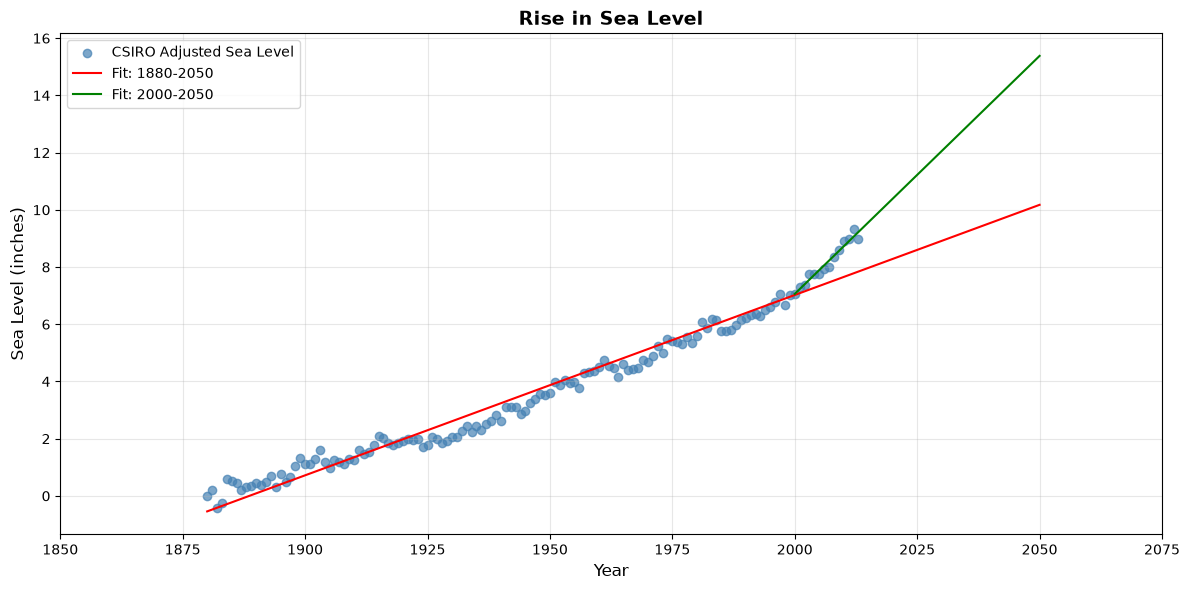

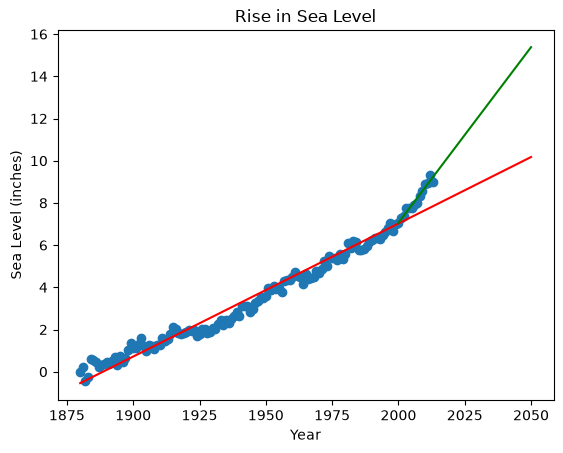

In [4]:
# Cell 4: Modern Accelerated Trend (2000 - Present) & Extrapolation
df_recent = df[df['Year'] >= 2000]
res2 = linregress(df_recent['Year'], df_recent['CSIRO Adjusted Sea Level'])
print(f'2000+ Accelerated Slope: {res2.slope:.6f} inches/year')
print(f'2000+ Intercept: {res2.intercept:.6f}')
print(f'Recent Correlation (r): {res2.rvalue:.4f} (R² = {res2.rvalue**2:.4f})')

# Project line to 2050
x_pred2 = pd.Series(range(2000, 2051))
y_pred2 = res2.slope * x_pred2 + res2.intercept
print(f'Estimated Sea Level in 2050 (Recent 2000+ slope): {y_pred2.iloc[-1]:.2f} inches')
print(f'Difference in projected sea level rise: {y_pred2.iloc[-1] - y_pred1.iloc[-1]:.2f} inches')

# Draw Comprehensive Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df['Year'], df['CSIRO Adjusted Sea Level'], alpha=0.7, color='steelblue', label='CSIRO Adjusted Sea Level')
ax.plot(x_pred1, y_pred1, 'r', label='Fit: 1880-2050')
ax.plot(x_pred2, y_pred2, 'green', label='Fit: 2000-2050')
ax.set_title('Rise in Sea Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Sea Level (inches)', fontsize=12)
ax.set_xticks([1850.0, 1875.0, 1900.0, 1925.0, 1950.0, 1975.0, 2000.0, 2025.0, 2050.0, 2075.0])
ax.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Call sea_level_predictor.draw_plot() to verify module
ax_mod = sea_level_predictor.draw_plot()
plt.show()

test_plot_data_points (test_module.LinePlotTestCase.test_plot_data_points) ... 

ok


test_plot_labels (test_module.LinePlotTestCase.test_plot_labels) ... 

ok


test_plot_lines (test_module.LinePlotTestCase.test_plot_lines) ... 

ok


test_plot_title (test_module.LinePlotTestCase.test_plot_title) ... 

ok


----------------------------------------------------------------------
Ran 4 tests in 1.200s

OK



All 4 integration tests passed successfully!


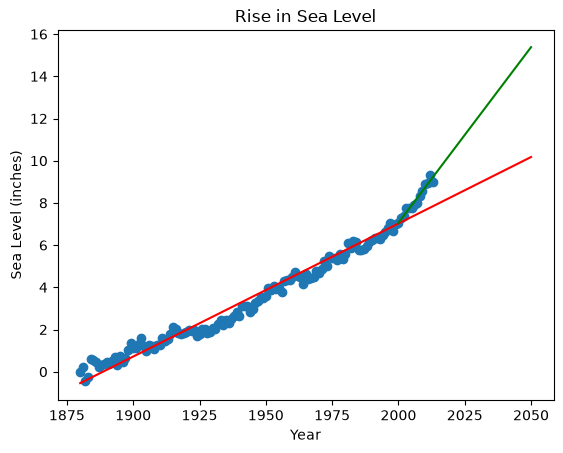

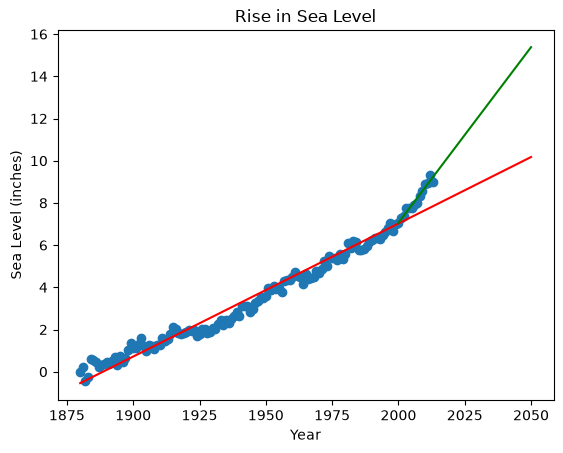

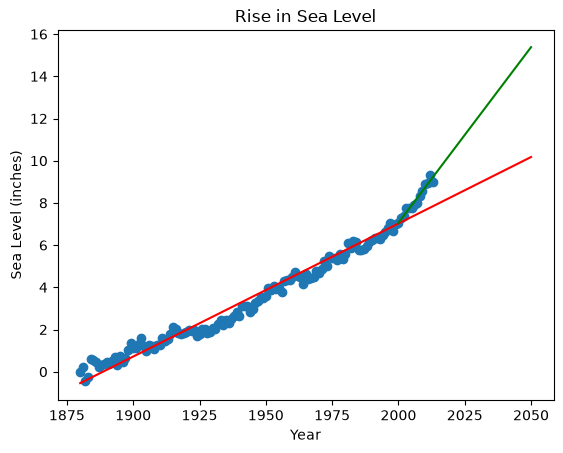

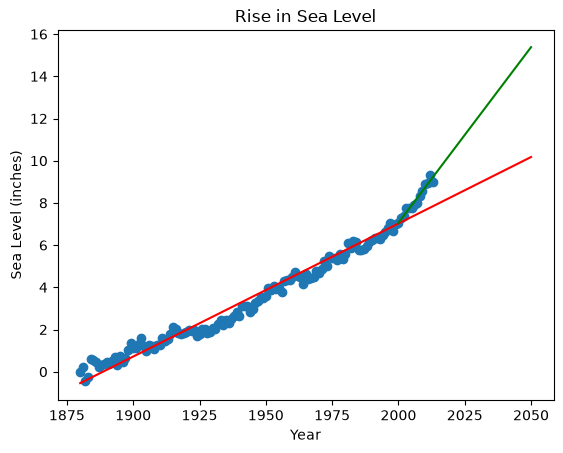

In [5]:
# Final Cell: Integration Test Runner
import unittest
import test_module

suite = unittest.defaultTestLoader.loadTestsFromModule(test_module)
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)
assert result.wasSuccessful(), 'Sea Level Predictor unit tests failed!'
print('\nAll 4 integration tests passed successfully!')